# TMR4240 Project – Plant Tests

This notebook describes **what the simulation plant consists of** and runs a series of
open-loop tests so you can see — before writing any controller — how the vessel responds
to thruster commands and environmental loads, and which direction is which.

## What the plant consists of

`simulation/plant.py` (`GunnerusPlant3DOF`) chains three provided components:

1. **Thruster dynamics** (`models/thruster_dynamics.py`) — takes your thrust and azimuth
   *commands* and converts the actual thrusts into a BODY wrench $[F_x, F_y, M_z]$ using
   the thruster positions. With the dynamics enabled it also applies rate limits
   (thrust ramp, azimuth rotation speed) and thrust saturation; with ideal actuators
   (Part 1) commands are applied exactly as requested.
2. **Vessel dynamics** (`models/gunnerus_3dof.py` → mcsimpy) — the 3-DOF Gunnerus
   equations $M\dot\nu + C_{RB}(\nu)\nu + C_A(\nu_r)\nu_r + D(\nu_r)\nu_r = \tau$, with
   ocean current entering through the relative velocity $\nu_r$.
3. **Environmental loads** — wind, waves, and any external load enter as generalized
   6-DOF BODY wrenches $[F_x, F_y, F_z, M_x, M_y, M_z]$; the current as a 6-DOF NED
   velocity $[V_N, V_E, V_D, 0, 0, 0]$ ("towards" convention).

All interface vectors are 6-DOF; the plant reduces to surge/sway/yaw (indices $[0,1,5]$)
internally. See the *Array Conventions* section of the README.

## 1. Thruster layout

The default Gunnerus-like arrangement has a bow tunnel thruster and two stern azimuths —
first the numbers, then a sketch drawn straight from the configuration (arrows show the
default thrust direction $\alpha_0$):

In [1]:
import sys
sys.path.insert(0, "..")  # allow running without installing the project package

import numpy as np
import matplotlib.pyplot as plt

from part_1.config import default_thrusters_gunnerus3
from simulation.plant import GunnerusPlant3DOF
from simulation.utils import Rz

thrusters = default_thrusters_gunnerus3()
print(f"{'name':<12} {'kind':<8} {'x [m]':>6} {'y [m]':>6} {'u_max [kN]':>11} "
      f"{'rate [kN/s]':>12} {'rot [deg/s]':>12} {'alpha0 [deg]':>13}")
for th in thrusters:
    print(f"{th.name:<12} {th.kind:<8} {th.x:>6.1f} {th.y:>6.1f} {th.u_max/1e3:>11.0f} "
          f"{th.u_rate/1e3:>12.0f} {np.rad2deg(th.rot_speed):>12.1f} {np.rad2deg(th.alpha0):>13.1f}")

# --- Sketch of the configuration: top view, bow up --------------------------
LPP, BEAM = 33.9, 9.6                   # R/V Gunnerus main dimensions
HULL = np.array([                       # hull outline in BODY coords (bow at +x)
    [+LPP/2, 0.0], [+LPP/6, +BEAM/2], [-LPP/2, +BEAM/2],
    [-LPP/2, -BEAM/2], [+LPP/6, -BEAM/2], [+LPP/2, 0.0],
])

def half_beam(x):
    # local half-width of the hull outline at station x (tapers toward the bow)
    if x <= LPP/6:
        return BEAM/2
    return BEAM/2 * (LPP/2 - x) / (LPP/2 - LPP/6)

fig, ax = plt.subplots(figsize=(4.6, 7.5))
ax.plot(HULL[:, 1], HULL[:, 0], "k-", lw=1.5)
ax.plot(0, 0, "k+", ms=12, mew=2)
ax.annotate("CO", (0, 0), textcoords="offset points", xytext=(7, 5), fontsize=9)

ARROW = 4.5                             # arrow length [m]
for th in thrusters:
    px, py = th.y, th.x                 # plot: horizontal = y (starboard), vertical = x (bow)
    dx, dy = np.sin(th.alpha0), np.cos(th.alpha0)   # alpha0 direction in plot coords
    if th.kind == "tunnel":
        color = "C3"
        b = half_beam(th.x)             # the tunnel runs through the hull
        ax.plot([-b, +b], [th.x, th.x], color=color, lw=6, alpha=0.35,
                solid_capstyle="butt")
        for sgn, ls in [(+1, "-"), (-1, "--")]:     # thrust is signed: both directions
            ax.annotate("", xy=(px + sgn * ARROW * dx, py + sgn * ARROW * dy),
                        xytext=(px, py),
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8, ls=ls))
        offset, ha = (16, 10), "left"
    else:
        color = "C0"
        ax.add_patch(plt.Circle((px, py), 1.0, fill=False, color=color, lw=1.5))
        ax.add_patch(plt.Circle((px, py), 2.0, fill=False, color=color, lw=1.0,
                                ls=":", alpha=0.7))  # dotted ring: it can rotate
        ax.annotate("", xy=(px + ARROW * dx, py + ARROW * dy), xytext=(px, py),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.8))
        side = 1 if th.y >= 0 else -1
        offset, ha = (14 * side, -4), "left" if side > 0 else "right"
    ax.annotate(f"{th.name}\n(x={th.x:.0f} m, y={th.y:.0f} m)", (px, py), fontsize=8,
                color=color, ha=ha, textcoords="offset points", xytext=offset)

handles = [plt.Line2D([], [], color="C3", label="tunnel: fixed athwartships, thrust signed ±"),
           plt.Line2D([], [], color="C0", marker="o", mfc="none",
                      label=r"azimuth: rotatable, arrow = $\alpha_0$")]
ax.legend(handles=handles, loc="lower center", fontsize=8, framealpha=0.9)
ax.set_xlabel(r"$y_{body}$ — to starboard [m]"); ax.set_ylabel(r"$x_{body}$ — to bow [m]")
ax.set_title("Thruster configuration (top view, bow up)")
ax.grid(True, alpha=0.3); ax.axis("equal"); ax.set_xlim(-14, 14)
plt.show()

name         kind      x [m]  y [m]  u_max [kN]  rate [kN/s]  rot [deg/s]  alpha0 [deg]
Tunnel_Bow   tunnel     12.0    0.0          32            4          0.0          90.0
Azimuth_1    azimuth   -13.0    3.0          80           10         12.0           0.0
Azimuth_2    azimuth   -13.0   -3.0          80           10         12.0           0.0


<Figure size 460x750 with 1 Axes>

In [2]:
# ▶ Playground: choose thrusts and angles, see the net BODY wrench [Fx, Fy, Mz].
# This is the mapping tau = B(alpha) u — the one your thrust allocation must invert.
from models.thruster_dynamics import ThrusterSet

my_thrust = [10e3, 20e3, 20e3]                        # [Tunnel_Bow, Azimuth_1, Azimuth_2] [N]
my_angle  = [0.0, np.deg2rad(30), np.deg2rad(-30)]    # [rad]; the tunnel angle is fixed anyway

ts = ThrusterSet(thrusters, dynamics=False)           # ideal actuators: no ramps
u_act, a_act, tau = ts.step(my_thrust, my_angle, 0.05)
print(f"actual thrusts [kN]:  {np.round(u_act / 1e3, 1)}")
print(f"actual angles [deg]:  {np.round(np.rad2deg(a_act), 1)}")
print(f"BODY wrench: Fx = {tau[0]/1e3:7.1f} kN,  Fy = {tau[1]/1e3:7.1f} kN,  "
      f"Mz = {tau[2]/1e3:8.1f} kNm")

actual thrusts [kN]:  [10. 20. 20.]
actual angles [deg]:  [ 90.  30. -30.]
BODY wrench: Fx =    34.6 kN,  Fy =    10.0 kN,  Mz =    120.0 kNm


The tunnel thruster is fixed athwartships ($\alpha_0 = 90°$): **positive thrust pushes
the bow to starboard**. The azimuths can rotate freely, but only at ~12 °/s — commands
are not applied instantly (when the dynamics are enabled).

## 2. Test setup — the plant API

One call runs a whole open-loop experiment:

```python
r = plant.run(T, thrust_command, azimuth_command,
              current=..., wind=..., waves=..., external=...)
```

| Argument | Meaning |
|---|---|
| `T` | simulation length [s] |
| `thrust_command` | **one signed thrust per thruster [N]**, in the table order above: `[Tunnel_Bow, Azimuth_1, Azimuth_2]` |
| `azimuth_command` | **one angle per thruster [rad]**, same order; `0` = forward, `+π/2` = to starboard; ignored for the tunnel (fixed) |
| `current` | NED velocity (6,), `[V_N, V_E, V_D, 0, 0, 0]` [m/s] |
| `wind`, `waves`, `external` | BODY 6-DOF wrench, constant or callable `load(t, eta, nu)` |
| `eta0`, `nu0` | optional initial state (6,), zeros by default; e.g. `eta0=[0, 0, 0, 0, 0, psi0]` starts at heading $\psi_0$ |

It returns a dict of stacked histories: `r["t"]`, `r["eta"]` (n×6 positions), `r["nu"]`
(n×6 velocities), `r["thrust"]`, `r["azimuth"]` (actual actuator states), `r["tau_*"]`
(load contributions). Commands may also be callables of time `f(t)`.

Below we create one plant per actuator mode, plus plotting helpers that draw the vessel
outline (R/V Gunnerus: $L_{pp} = 33.9$ m, $B = 9.6$ m) at its true position and heading
along each track:

In [3]:
DT = 0.05   # simulation timestep [s]; LPP / BEAM / HULL come from the layout cell above

# One plant per actuator mode; plant.run(T, thrust, azimuth, ...) does the stepping
# and returns stacked histories as a dict of arrays.
plant = GunnerusPlant3DOF(default_thrusters_gunnerus3(), dt=DT)                  # dynamics ON
plant_ideal = GunnerusPlant3DOF(default_thrusters_gunnerus3(), dt=DT,
                                thruster_dynamics=False)                         # Part 1 mode

# Shared initial state, passed to every test below — edit to start anywhere.
# (Section 5 keeps the position but overrides the heading psi.)
#         [  N,   E,   z, phi, theta, psi]
ETA0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


def draw_vessel(ax, N, E, psi, color="k", alpha=0.8, lw=1.2, thrust=None, azimuth=None):
    # draw the hull outline at (N, E) with heading psi (East on x-axis, North on y-axis);
    # if actual thrust/azimuth states are given, draw each thruster's thrust vector at
    # its position (arrow length: 8 m at u_max).
    c, s = np.cos(psi), np.sin(psi)
    n = HULL[:, 0] * c - HULL[:, 1] * s
    e = HULL[:, 0] * s + HULL[:, 1] * c
    ax.plot(E + e, N + n, color=color, alpha=alpha, lw=lw)
    if thrust is None or azimuth is None:
        return
    for th, u, a in zip(thrusters, thrust, azimuth):
        if abs(u) < 0.01 * th.u_max:            # idle thruster: no arrow
            continue
        n0 = N + th.x * c - th.y * s            # thruster position in NED
        e0 = E + th.x * s + th.y * c
        L = 8.0 * u / th.u_max                  # signed arrow length [m]
        bx, by = L * np.cos(a), L * np.sin(a)   # thrust vector in BODY
        ax.annotate("", xy=(e0 + bx * s + by * c, n0 + bx * c - by * s), xytext=(e0, n0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.4,
                                    alpha=min(1.0, alpha + 0.15)))


def plot_tracks(runs, title, n_ships=5):
    # runs: {label: full run dict from plant.run -> hulls + actual-thrust arrows,
    #        or a bare eta history -> hulls only}
    # Marine plot convention: East on x-axis, North on y-axis. The hull (to scale,
    # Lpp x B) is drawn along each track, fading in toward the end.
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for label, run in runs.items():
        eta = run["eta"] if isinstance(run, dict) else run
        thr = run["thrust"] if isinstance(run, dict) else None
        azi = run["azimuth"] if isinstance(run, dict) else None
        line, = ax.plot(eta[:, 1], eta[:, 0], label=label)
        for k in np.linspace(0, len(eta) - 1, n_ships).astype(int):
            draw_vessel(ax, eta[k, 0], eta[k, 1], eta[k, 5], color=line.get_color(),
                        alpha=0.25 + 0.55 * k / max(len(eta) - 1, 1),
                        thrust=None if thr is None else thr[k],
                        azimuth=None if azi is None else azi[k])
    ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]")
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.axis("equal"); ax.legend()
    plt.show()

print("harness ready")

harness ready


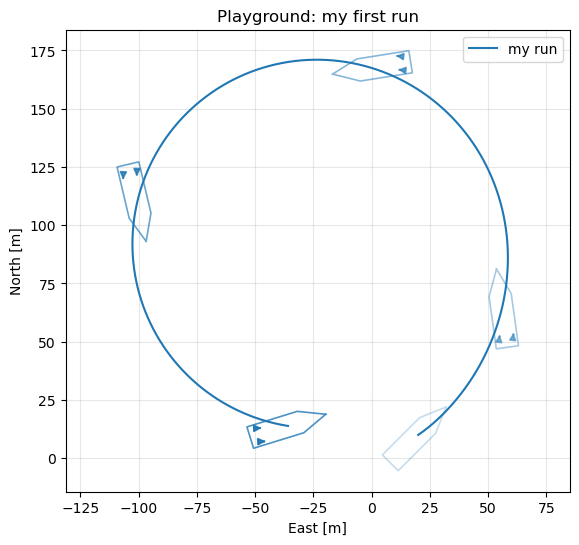

final: N = 13.8 m, E = -35.9 m, psi = 72.8°


In [4]:
# ▶ Playground: a free-form run — edit the commands, times, and start pose, then re-run.
# Tip: commands may be callables of time, e.g.
#   thrust_command=lambda t: [0, 40e3 * (t > 30), 40e3 * (t > 30)]
# (eta0_play is local to this cell; the global ETA0 above feeds all other sections.)
eta0_play  = [10.0, 20.0, 0.0, 0.0, 0.0, np.pi/4]     # start at (N, E) = (10, 20) m, psi = 45°
my_thrust  = [0.0, 20e3, 20e3]                        # [Tunnel_Bow, Azimuth_1, Azimuth_2] [N]
my_azimuth = [0.0, np.deg2rad(15), np.deg2rad(15)]    # [rad]
run_time   = 200.0                                    # [s]

r = plant.run(T=run_time, thrust_command=my_thrust, azimuth_command=my_azimuth,
              eta0=eta0_play)
plot_tracks({"my run": r}, "Playground: my first run")   # full run dict -> thrust arrows
print(f"final: N = {r['eta'][-1, 0]:.1f} m, E = {r['eta'][-1, 1]:.1f} m, "
      f"psi = {np.rad2deg(r['eta'][-1, 5]):.1f}°")

## 3. Maneuver tests

Every test starts from `ETA0` (set in the harness cell above — default: origin, bow
pointing **North**). The expected outcomes below assume the default $\psi_0 = 0$; change
`ETA0` and re-run to see the same commands play out from another position or heading:

| Test | Command | Expected motion |
|---|---|---|
| Ahead | both azimuths $+40$ kN, $\alpha = 0$ | straight North |
| Astern | both azimuths $-40$ kN | straight South |
| Pure sway | tunnel $+26$ kN, azimuths $+12$ kN at $\alpha = 90°$ | drift East, little yaw |
| Tunnel only, + / − | $\pm 20$ kN | bow pushed to starboard/port: yaw + slight sway |
| Yaw spin | azimuths $+30 / -30$ kN | rotation on the spot |

The sway case balances yaw moments: bow force at $x = +12$ m against stern force at
$x = -13$ m, so $12\,F_{bow} \approx 13\,F_{stern}$.

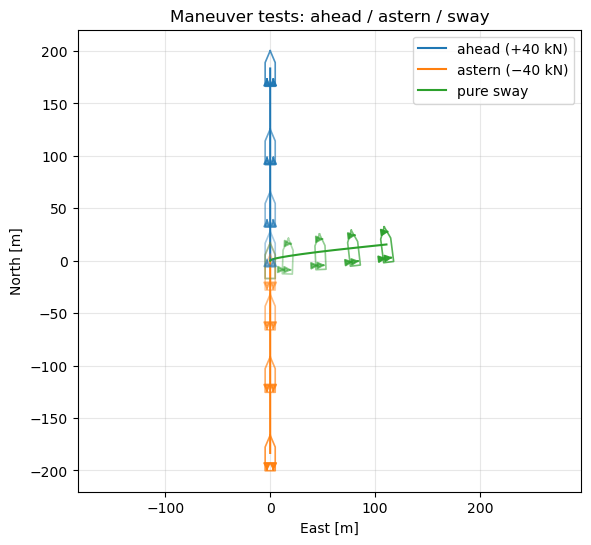

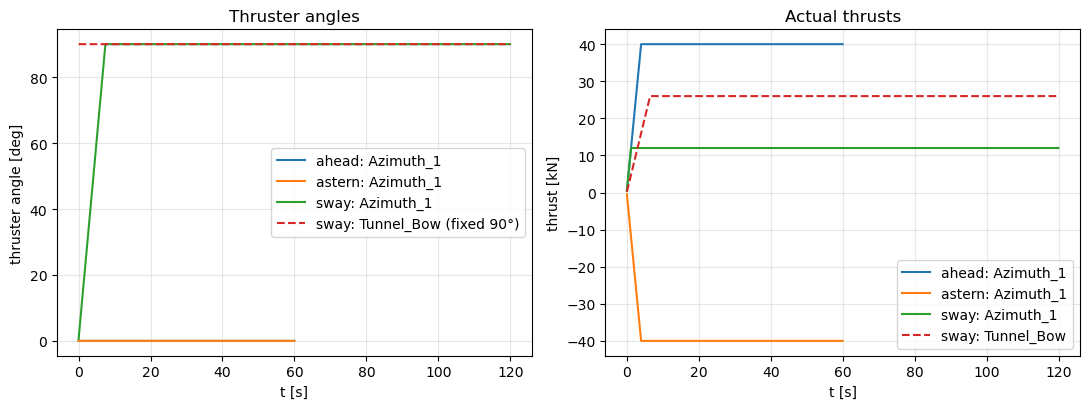

ahead : final N =   183.3 m, E =    0.0 m, psi =    0.0 deg
astern: final N =  -183.3 m, E =    0.0 m, psi =    0.0 deg
sway  : final N =    15.5 m, E =  110.9 m, psi =   -7.2 deg


In [5]:
# Commands: one value per thruster, in the thruster-table order
#                 [Tunnel_Bow, Azimuth_1, Azimuth_2]
ahead_thrust   = [       0.0,      40e3,      40e3]   # thrust [N], signed
astern_thrust  = [       0.0,     -40e3,     -40e3]
forward_angle  = [       0.0,       0.0,       0.0]   # angle [rad]: 0 = thrust forward

# Pure sway: azimuths turned +90° (to starboard); bow 26 kN balances stern 2x12 kN
# so the yaw moments cancel: 12 m * 26 kN ≈ 13 m * 24 kN.
sway_thrust    = [      26e3,      12e3,      12e3]
sway_angle     = [       0.0,   np.pi/2,   np.pi/2]

r_f = plant.run(T=60,  thrust_command=ahead_thrust,  azimuth_command=forward_angle, eta0=ETA0)
r_b = plant.run(T=60,  thrust_command=astern_thrust, azimuth_command=forward_angle, eta0=ETA0)
r_s = plant.run(T=120, thrust_command=sway_thrust,   azimuth_command=sway_angle,    eta0=ETA0)

# passing the full run dicts draws the actual thrust vector on every hull snapshot
plot_tracks({"ahead (+40 kN)": r_f, "astern (−40 kN)": r_b, "pure sway": r_s},
            "Maneuver tests: ahead / astern / sway")

# What the thrusters actually did: angles and thrusts (rate-limited)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, r in [("ahead", r_f), ("astern", r_b), ("sway", r_s)]:
    axes[0].plot(r["t"], np.rad2deg(r["azimuth"][:, 1]), label=f"{name}: Azimuth_1")
    axes[1].plot(r["t"], r["thrust"][:, 1] / 1e3, label=f"{name}: Azimuth_1")
axes[0].plot(r_s["t"], np.rad2deg(r_s["azimuth"][:, 0]), "--", label="sway: Tunnel_Bow (fixed 90°)")
axes[1].plot(r_s["t"], r_s["thrust"][:, 0] / 1e3, "--", label="sway: Tunnel_Bow")
axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("thruster angle [deg]")
axes[0].set_title("Thruster angles"); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("thrust [kN]")
axes[1].set_title("Actual thrusts"); axes[1].grid(True, alpha=0.3); axes[1].legend()
fig.tight_layout(); plt.show()

for name, r in [("ahead ", r_f), ("astern", r_b), ("sway  ", r_s)]:
    eta = r["eta"]
    print(f"{name}: final N = {eta[-1,0]:7.1f} m, E = {eta[-1,1]:6.1f} m, "
          f"psi = {np.rad2deg(eta[-1,5]):6.1f} deg")

Note the ramp: even with a constant command, the thrust builds up at the rate limit
(10 kN/s for the azimuths), and the azimuth angles rotate to 90° at 12 °/s in the sway
test — one reason the sway track is not perfectly straight at the start.

### Tunnel thruster to both sides, and a yaw spin

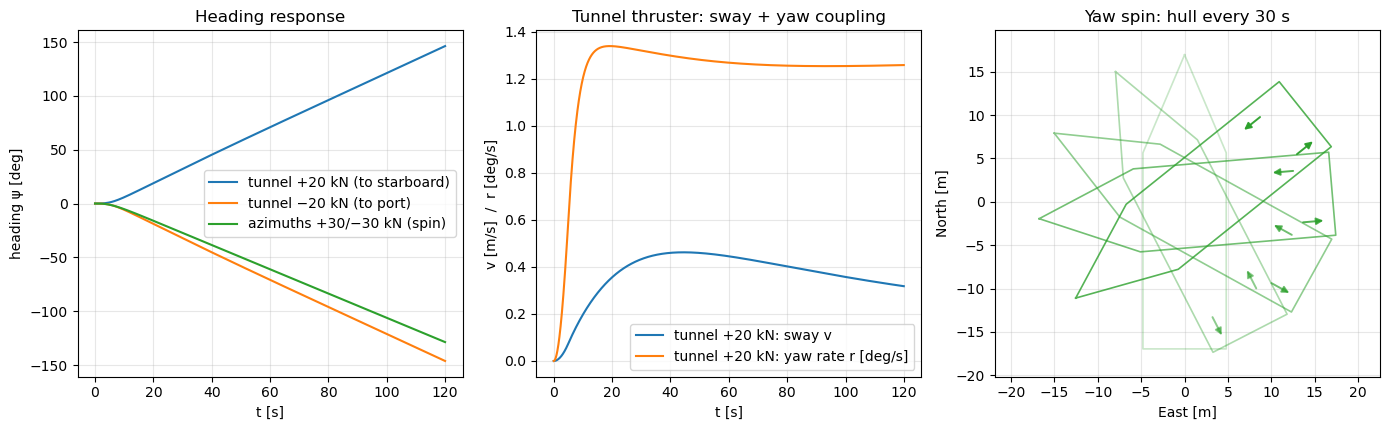

yaw spin: heading after 120 s = -128.7 deg, position drift = 0.8 m


In [6]:
# [Tunnel_Bow, Azimuth_1, Azimuth_2] — tunnel only (azimuths idle), then a spin
tunnel_stbd  = [+20e3,    0.0,    0.0]   # tunnel pushes bow to starboard
tunnel_port  = [-20e3,    0.0,    0.0]   # tunnel pushes bow to port
spin_thrust  = [  0.0, +30e3,  -30e3]    # opposed stern thrusts -> pure yaw moment
forward_angle = [ 0.0,    0.0,    0.0]

r_tp = plant.run(T=120, thrust_command=tunnel_stbd, azimuth_command=forward_angle, eta0=ETA0)
r_tm = plant.run(T=120, thrust_command=tunnel_port, azimuth_command=forward_angle, eta0=ETA0)
r_y  = plant.run(T=120, thrust_command=spin_thrust, azimuth_command=forward_angle, eta0=ETA0)
t, eta_y = r_y["t"], r_y["eta"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].plot(t, np.rad2deg(r_tp["eta"][:, 5]), label="tunnel +20 kN (to starboard)")
axes[0].plot(t, np.rad2deg(r_tm["eta"][:, 5]), label="tunnel −20 kN (to port)")
axes[0].plot(t, np.rad2deg(eta_y[:, 5]),       label="azimuths +30/−30 kN (spin)")
axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("heading ψ [deg]")
axes[0].set_title("Heading response"); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(t, r_tp["nu"][:, 1], label="tunnel +20 kN: sway v")
axes[1].plot(t, np.rad2deg(r_tp["nu"][:, 5]), label="tunnel +20 kN: yaw rate r [deg/s]")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("v [m/s]  /  r [deg/s]")
axes[1].set_title("Tunnel thruster: sway + yaw coupling")
axes[1].grid(True, alpha=0.3); axes[1].legend()

# hull snapshots of the yaw spin, every 30 s — the vessel rotates on the spot;
# the opposed thrust arrows (+30 / −30 kN) show the couple driving it
for k in np.linspace(0, len(eta_y) - 1, 5).astype(int):
    draw_vessel(axes[2], eta_y[k, 0], eta_y[k, 1], eta_y[k, 5], color="C2",
                alpha=0.25 + 0.55 * k / (len(eta_y) - 1),
                thrust=r_y["thrust"][k], azimuth=r_y["azimuth"][k])
axes[2].set_xlabel("East [m]"); axes[2].set_ylabel("North [m]")
axes[2].set_title("Yaw spin: hull every 30 s")
axes[2].grid(True, alpha=0.3); axes[2].axis("equal")
fig.tight_layout(); plt.show()

print(f"yaw spin: heading after 120 s = {np.rad2deg(eta_y[-1,5]):.1f} deg, "
      f"position drift = {np.hypot(*(eta_y[-1,:2] - eta_y[0,:2])):.1f} m")

### Azimuth thrusters: dynamics ON vs OFF

The plant has a switch for the actuator dynamics
(`GunnerusPlant3DOF(..., thruster_dynamics=...)`, and `SimConfig(thruster_dynamics=...)`
in the closed-loop simulator):

- **ON**: thrust ramps at `u_rate`, azimuths rotate at `rot_speed`, and thrust saturates
  at `u_max` — realistic actuators.
- **OFF** (*used in Project Part 1*): ideal actuators — commands are applied exactly as
  requested, with no rate limits and no saturation.

The effect is largest for the **azimuths**: rotating from 0° to 90° takes ~7.5 s, and
during that time their thrust points *forward*, not sideways. Commanding the pure-sway
maneuver in both modes — first what the actuators actually do:

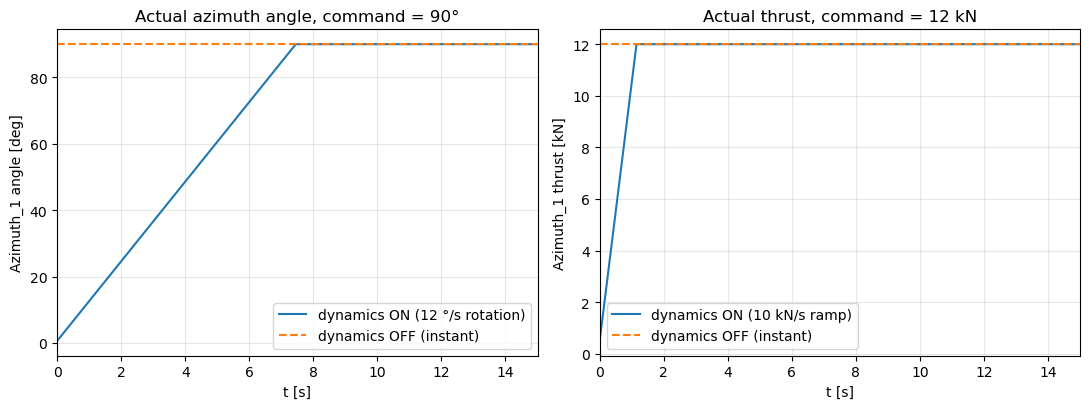

In [7]:
# Same pure-sway command as above, run in both actuator modes
r_on  = plant.run(T=120, thrust_command=sway_thrust, azimuth_command=sway_angle,
                  eta0=ETA0)                                                     # dynamics ON
r_off = plant_ideal.run(T=120, thrust_command=sway_thrust, azimuth_command=sway_angle,
                        eta0=ETA0)                                               # dynamics OFF (Part 1)
t = r_on["t"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(t, np.rad2deg(r_on["azimuth"][:, 1]), label="dynamics ON (12 °/s rotation)")
axes[0].plot(t, np.rad2deg(r_off["azimuth"][:, 1]), "--", label="dynamics OFF (instant)")
axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("Azimuth_1 angle [deg]")
axes[0].set_title("Actual azimuth angle, command = 90°")
axes[0].set_xlim(0, 15); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(t, r_on["thrust"][:, 1] / 1e3, label="dynamics ON (10 kN/s ramp)")
axes[1].plot(t, r_off["thrust"][:, 1] / 1e3, "--", label="dynamics OFF (instant)")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("Azimuth_1 thrust [kN]")
axes[1].set_title("Actual thrust, command = 12 kN")
axes[1].set_xlim(0, 15); axes[1].grid(True, alpha=0.3); axes[1].legend()
fig.tight_layout(); plt.show()

While the azimuths are still rotating, their thrust points forward — so with dynamics ON
the vessel first **surges ahead** and picks up a yaw offset before the sway develops. The
tracks with the hull drawn make this visible:

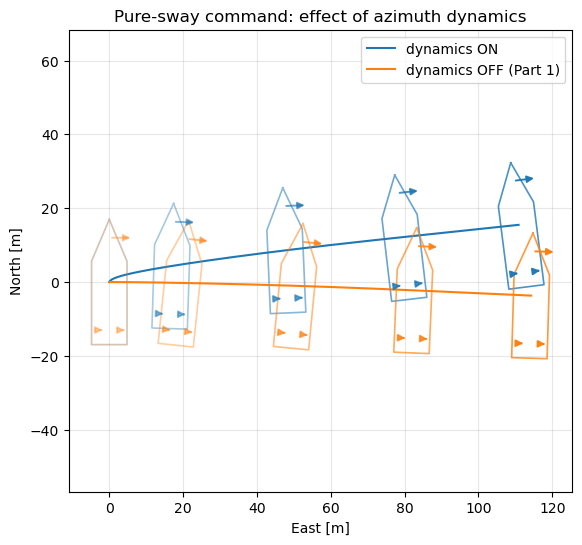

pure sway after 120 s:
  dynamics ON : N =   15.5 m, E =  110.9 m, psi =   -7.2 deg
  dynamics OFF: N =   -3.7 m, E =  114.3 m, psi =    1.7 deg


In [8]:
# full run dicts -> the thrust arrows show the azimuths still pointing forward at first
plot_tracks({"dynamics ON": r_on, "dynamics OFF (Part 1)": r_off},
            "Pure-sway command: effect of azimuth dynamics")

print("pure sway after 120 s:")
for label, r in [("dynamics ON ", r_on), ("dynamics OFF", r_off)]:
    eta = r["eta"]
    print(f"  {label}: N = {eta[-1,0]:6.1f} m, E = {eta[-1,1]:6.1f} m, "
          f"psi = {np.rad2deg(eta[-1,5]):6.1f} deg")

### Saturation: the ideal plant will not protect you

With the dynamics **ON**, thrust is not only rate-limited — it also saturates at
$u_{max}$ (32 kN tunnel, 80 kN azimuths). With ideal actuators (**Part 1**) there is
no saturation either: the plant delivers *exactly* what you command, even a physically
impossible 120 kN. Respecting $u_{max}$ is therefore your **thrust allocation's** job
in Part 1 — the plant will not clip a bad command for you, it will happily apply it and
your results will look better than any real vessel could. Commanding far more than the
thrusters can deliver, in both modes:

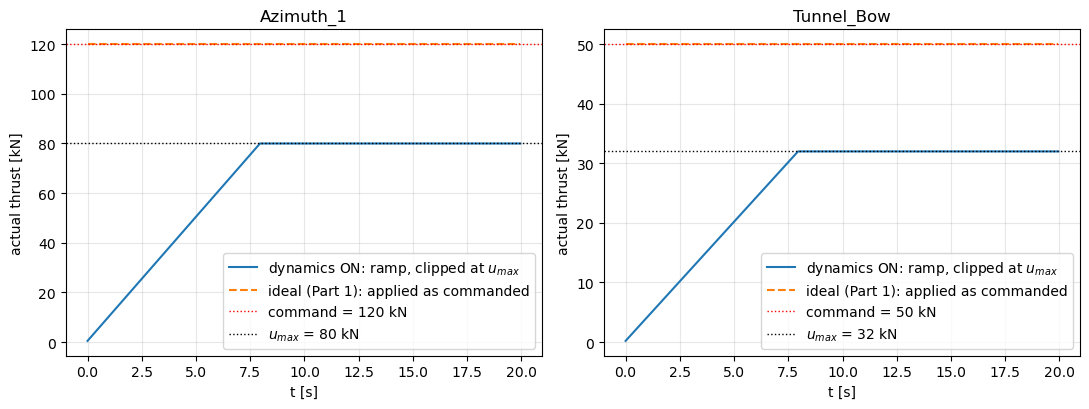

dynamics ON   : final thrusts = [ 32.0,  80.0,  80.0] kN   (commanded [ 50.0, 120.0, 120.0] kN)
ideal (Part 1): final thrusts = [ 50.0, 120.0, 120.0] kN   (commanded [ 50.0, 120.0, 120.0] kN)


In [9]:
# Command far beyond the limits: tunnel u_max = 32 kN, azimuths u_max = 80 kN.
# Dynamics ON ramps and clips at u_max; ideal actuators apply the raw command.
over_thrust = [50e3, 120e3, 120e3]

r_sat_on  = plant.run(T=20, thrust_command=over_thrust, azimuth_command=forward_angle,
                      eta0=ETA0)
r_sat_off = plant_ideal.run(T=20, thrust_command=over_thrust, azimuth_command=forward_angle,
                            eta0=ETA0)
t = r_sat_on["t"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, i in [(axes[0], 1), (axes[1], 0)]:
    th = thrusters[i]
    ax.plot(t, r_sat_on["thrust"][:, i] / 1e3, label="dynamics ON: ramp, clipped at $u_{max}$")
    ax.plot(t, r_sat_off["thrust"][:, i] / 1e3, "--",
            label="ideal (Part 1): applied as commanded")
    ax.axhline(over_thrust[i] / 1e3, color="r", ls=":", lw=1,
               label=f"command = {over_thrust[i]/1e3:.0f} kN")
    ax.axhline(th.u_max / 1e3, color="k", ls=":", lw=1,
               label=f"$u_{{max}}$ = {th.u_max/1e3:.0f} kN")
    ax.set_xlabel("t [s]"); ax.set_ylabel("actual thrust [kN]")
    ax.set_title(th.name); ax.grid(True, alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

for name, r in [("dynamics ON   ", r_sat_on), ("ideal (Part 1)", r_sat_off)]:
    got = ", ".join(f"{v:5.1f}" for v in r["thrust"][-1] / 1e3)
    cmd = ", ".join(f"{v:5.1f}" for v in np.asarray(over_thrust) / 1e3)
    print(f"{name}: final thrusts = [{got}] kN   (commanded [{cmd}] kN)")

A positive tunnel command turns the bow to **starboard** (positive $\psi$, clockwise
from above) — because the tunnel sits forward of the pivot point, it produces mostly yaw
moment plus some sway. Check this against the sign conventions in your thrust allocation.

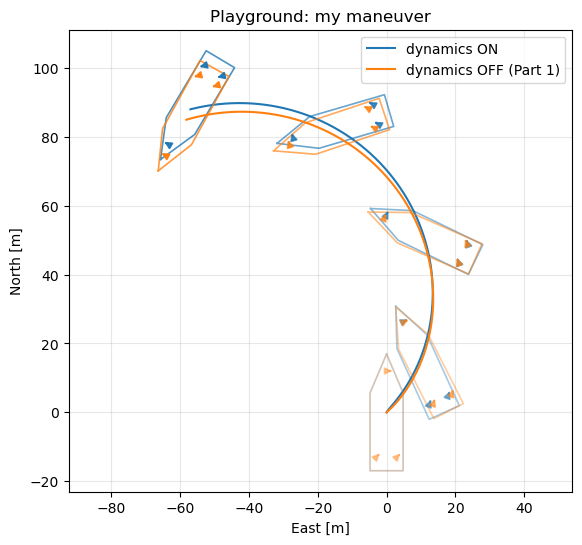

In [10]:
# ▶ Playground: any maneuver, both actuator modes side by side (with thrust arrows).
my_thrust  = [10e3, 15e3, 15e3]                       # [Tunnel_Bow, Azimuth_1, Azimuth_2] [N]
my_azimuth = [0.0, np.deg2rad(45), np.deg2rad(45)]    # [rad]
T_play = 120                                          # [s]

r_dyn = plant.run(T=T_play, thrust_command=my_thrust, azimuth_command=my_azimuth, eta0=ETA0)
r_idl = plant_ideal.run(T=T_play, thrust_command=my_thrust, azimuth_command=my_azimuth, eta0=ETA0)
plot_tracks({"dynamics ON": r_dyn, "dynamics OFF (Part 1)": r_idl},
            "Playground: my maneuver")

## 4. Environmental direction conventions

**Current** is a NED velocity, direction "towards": with no thrust, the vessel should
simply drift *in* the current direction. One run per cardinal direction:

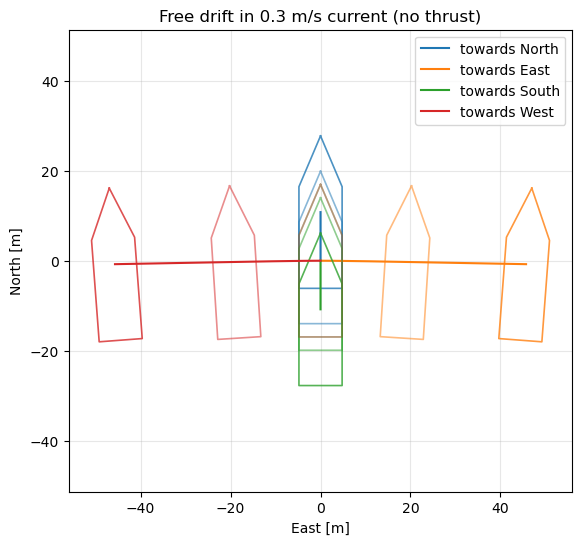

towards North: drift speed after 180 s = 0.103 m/s  (current: 0.3 m/s)
towards East : drift speed after 180 s = 0.298 m/s  (current: 0.3 m/s)
towards South: drift speed after 180 s = 0.103 m/s  (current: 0.3 m/s)
towards West : drift speed after 180 s = 0.298 m/s  (current: 0.3 m/s)


towards North after 1800 s: drift speed = 0.292 m/s — it does converge to U, just slowly (weak surge damping)


In [11]:
no_thrust = [0.0, 0.0, 0.0]   # all thrusters idle — the vessel drifts freely

U = 0.3   # current speed [m/s]; vector = [V_N, V_E, V_D, 0, 0, 0] in NED, "towards"
cardinal_currents = {
    "towards North": [+U, 0, 0, 0, 0, 0],
    "towards East":  [0, +U, 0, 0, 0, 0],
    "towards South": [-U, 0, 0, 0, 0, 0],
    "towards West":  [0, -U, 0, 0, 0, 0],
}
runs = {label: plant.run(T=180, thrust_command=no_thrust, azimuth_command=no_thrust,
                         current=cur, eta0=ETA0)["eta"]
        for label, cur in cardinal_currents.items()}
plot_tracks(runs, f"Free drift in {U} m/s current (no thrust)", n_ships=3)

# Quantitative check: the hull is dragged along until the relative velocity
# nu_r -> 0, i.e. until it drifts WITH the current at exactly U. Current is a
# velocity, not a force — and how fast the vessel gets there depends on the
# damping in that direction: large in sway (done well within 180 s), small in
# surge (time constant ~7 min), so the N/S runs are still accelerating here.
n30 = int(round(30.0 / DT))   # average over the last 30 s

def drift_speed(eta):
    return np.hypot(*(eta[-1, :2] - eta[-1 - n30, :2])) / (n30 * DT)

for label, eta in runs.items():
    print(f"{label:<13}: drift speed after 180 s = {drift_speed(eta):.3f} m/s  "
          f"(current: {U} m/s)")

r_long = plant.run(T=1800, thrust_command=no_thrust, azimuth_command=no_thrust,
                   current=cardinal_currents["towards North"], eta0=ETA0)
print(f"towards North after 1800 s: drift speed = {drift_speed(r_long['eta']):.3f} m/s "
      f"— it does converge to U, just slowly (weak surge damping)")

**Wind / wave / external loads** are BODY-frame wrenches. To apply a force that is fixed
in NED (e.g. "wind pushing towards the East"), rotate it into the body frame at every step
with $J^\top(\psi)$ — exactly what your wind model must do:

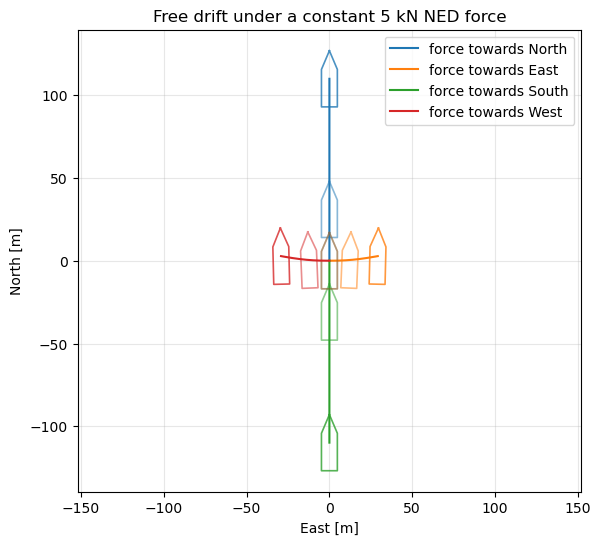

In [12]:
def ned_force(F_N, F_E):
    # constant NED force [N], converted to a BODY wrench each step
    def load(t, eta, nu):
        f_body = Rz(eta[5]).T @ np.array([F_N, F_E, 0.0])
        return [f_body[0], f_body[1], 0.0, 0.0, 0.0, 0.0]
    return load

F = 5e3   # 5 kN
cardinal_forces = {
    "force towards North": ned_force(+F, 0),
    "force towards East":  ned_force(0, +F),
    "force towards South": ned_force(-F, 0),
    "force towards West":  ned_force(0, -F),
}
runs = {label: plant.run(T=180, thrust_command=no_thrust, azimuth_command=no_thrust,
                         external=load, eta0=ETA0)["eta"]
        for label, load in cardinal_forces.items()}
plot_tracks(runs, "Free drift under a constant 5 kN NED force", n_ships=3)

The vessel drifts in the direction of the applied NED force — if your own wind model
produces drift in the wrong direction, the bug is almost always a missing $J^\top(\psi)$
rotation or a from/towards convention mix-up.

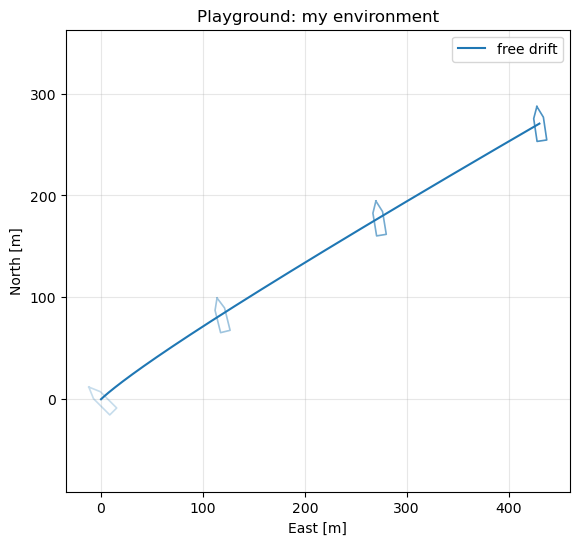

In [13]:
# ▶ Playground: free drift under a current plus a constant NED force and a constant
# BODY wrench — combine them and watch where the vessel goes.
# (eta0_env is local to this cell; the global ETA0 above feeds all other sections.)
my_current   = [1.0, 2.0, 0, 0, 0, 0]   # NED velocity, "towards" [m/s]
my_force_ned = np.zeros(6)              # constant NED force [N], rotated each step (off)
my_wind_body = [0, 0, 0, 0, 0, 0]       # constant BODY wrench [N, Nm] (off)
eta0_env = [0.0, 0.0, 0.0, 0.0, 0.0, -np.pi/4]   # start at (N, E) = (0, 0) m, psi = -45°

r = plant.run(T=240, thrust_command=no_thrust, azimuth_command=no_thrust,
              current=my_current, external=my_force_ned, wind=my_wind_body, eta0=eta0_env)
plot_tracks({"free drift": r["eta"]}, "Playground: my environment", n_ships=4)

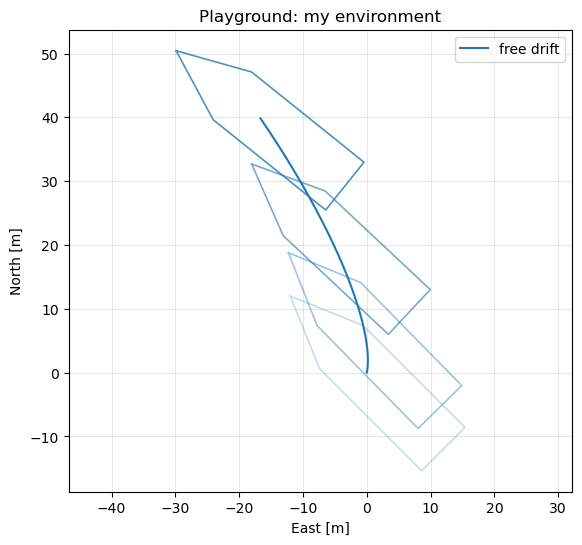

In [14]:
# ▶ Playground: a constant BODY wind wrench acting alone (no current, no NED force).
# (eta0_env is local to this cell; the global ETA0 above feeds all other sections.)
my_current   = [0.0, 0.0, 0, 0, 0, 0]        # NED velocity, "towards" [m/s] (off)
my_force_ned = np.zeros(6)                   # constant NED force [N] (off)
my_wind_body = [1.0e3, 2.0e3, 0, 0, 0, 0]    # constant BODY wrench (surge + sway force)
eta0_env = [0.0, 0.0, 0.0, 0.0, 0.0, -np.pi/4]   # start at (N, E) = (0, 0) m, psi = -45°

r = plant.run(T=240, thrust_command=no_thrust, azimuth_command=no_thrust,
              current=my_current, external=my_force_ned, wind=my_wind_body, eta0=eta0_env)
plot_tracks({"free drift": r["eta"]}, "Playground: my environment", n_ships=4)

## 5. Reference frames: the same command at a different heading

There is a catch in everything above: with the default `ETA0` every run starts at
$\psi_0 = 0$, where the BODY and NED frames **coincide** — so none of those tests could
tell them apart. At $\psi = 0$ a missing $J^\top(\psi)$ is the identity and changes
nothing! To see the frames separate, the runs below override the heading (the position
still comes from `ETA0`).

First, the *same* BODY-frame command — both azimuths ahead — from four initial headings.
Thruster commands are body-fixed, so the NED track follows the bow, not North:

psi0 =   0°: displacement ΔN =   183.3 m, ΔE =     0.0 m


psi0 =  90°: displacement ΔN =     0.0 m, ΔE =   183.3 m


psi0 = 180°: displacement ΔN =  -183.3 m, ΔE =    -0.0 m


psi0 = 270°: displacement ΔN =     0.0 m, ΔE =  -183.3 m


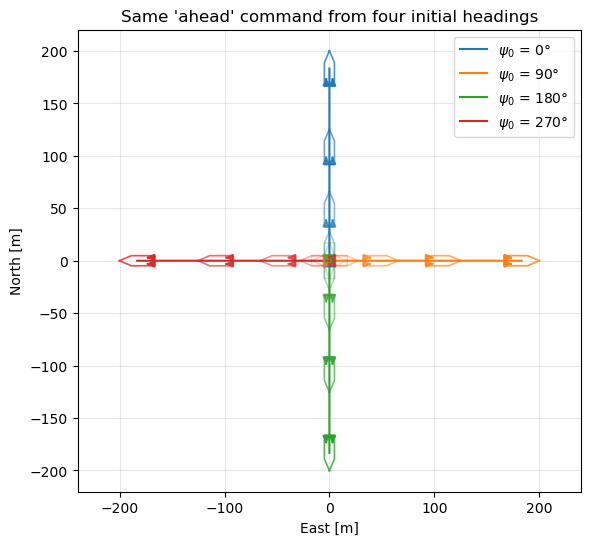

In [15]:
# Same position as ETA0, but the heading is overridden per run — that is the experiment
runs = {}
for psi0_deg in (0, 90, 180, 270):
    eta0 = list(ETA0[:5]) + [np.deg2rad(psi0_deg)]
    r = plant.run(T=60, thrust_command=ahead_thrust, azimuth_command=forward_angle,
                  eta0=eta0)
    eta = r["eta"]
    runs[f"$\\psi_0$ = {psi0_deg}°"] = r      # full dict -> thrust arrows on the hulls
    print(f"psi0 = {psi0_deg:>3}°: displacement ΔN = {eta[-1, 0] - eta[0, 0]:7.1f} m, "
          f"ΔE = {eta[-1, 1] - eta[0, 1]:7.1f} m")

plot_tracks(runs, "Same 'ahead' command from four initial headings")

The command was identical in all four runs — only the initial heading changed. What a
thrust command does in NED depends on $\psi$ through $J(\psi)$: your controller computes
a desired force in NED and must map it into BODY before allocation for exactly this reason.

Second, the $J^\top(\psi)$ demonstration promised above. The same 5 kN "towards East"
force, applied to a vessel starting at $\psi_0 = 120°$ — once correctly re-rotated into
BODY at every step (the `ned_force` helper), and once "forgotten": the same numbers passed
as a constant BODY wrench. At $\psi = 0$ the two are identical; at $\psi_0 = 120°$ the bug
is unmissable.

(Don't expect the correct run to head *exactly* East: with the hull at an oblique angle,
the anisotropic drag — much smaller in surge than in sway — skews the steady drift a few
tens of degrees toward the bow–stern axis. The bug, in contrast, is off by an entire
quadrant.)

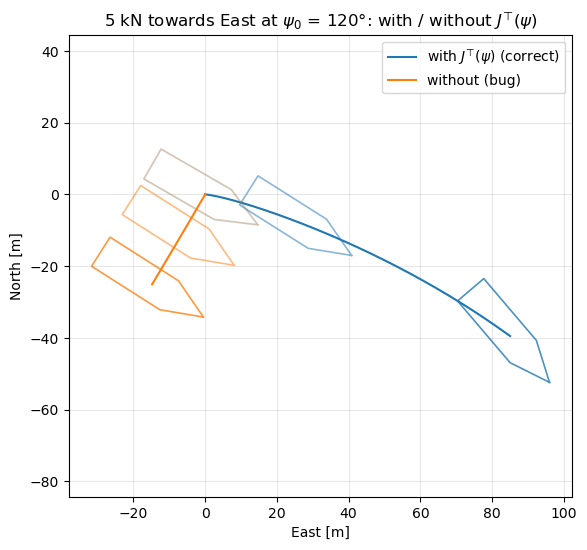

with $J^\top(\psi)$ (correct): drift direction =  114.9° (East = 90°)
without (bug): drift direction = -149.5° (East = 90°)


In [16]:
PSI0 = np.deg2rad(120)
eta0 = list(ETA0[:5]) + [PSI0]      # ETA0's position, heading overridden to 120°

correct = ned_force(0, +F)          # rotated with J^T(psi) at every step
buggy   = [0.0, F, 0, 0, 0, 0]      # same numbers, but as a constant BODY wrench

runs = {
    "with $J^\\top(\\psi)$ (correct)": plant.run(
        T=180, thrust_command=no_thrust, azimuth_command=no_thrust,
        external=correct, eta0=eta0)["eta"],
    "without (bug)": plant.run(
        T=180, thrust_command=no_thrust, azimuth_command=no_thrust,
        external=buggy, eta0=eta0)["eta"],
}
plot_tracks(runs, "5 kN towards East at $\\psi_0$ = 120°: with / without $J^\\top(\\psi)$",
            n_ships=3)

for label, eta in runs.items():
    d = np.rad2deg(np.arctan2(eta[-1, 1] - eta[0, 1], eta[-1, 0] - eta[0, 0]))
    print(f"{label}: drift direction = {d:6.1f}° (East = 90°)")

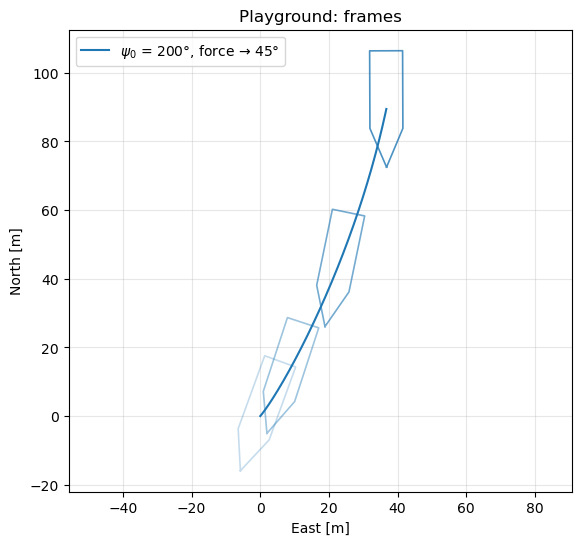

drift direction = 22.3°  (force direction: 45°)


In [17]:
# ▶ Playground: your own initial heading and NED force direction. The drift heads
# roughly where the force pushes, skewed toward the bow-stern axis (the hull slides
# much more easily in surge than in sway). A missing J^T rotation, in contrast,
# sends it somewhere else entirely.
psi0_deg  = 200    # initial heading [deg]
force_dir = 45     # NED direction the force pushes towards [deg]

load = ned_force(F * np.cos(np.deg2rad(force_dir)), F * np.sin(np.deg2rad(force_dir)))
r = plant.run(T=180, thrust_command=no_thrust, azimuth_command=no_thrust, external=load,
              eta0=list(ETA0[:5]) + [np.deg2rad(psi0_deg)])
eta = r["eta"]
plot_tracks({f"$\\psi_0$ = {psi0_deg}°, force → {force_dir}°": eta},
            "Playground: frames", n_ships=4)
d = np.rad2deg(np.arctan2(eta[-1, 1] - eta[0, 1], eta[-1, 0] - eta[0, 0]))
print(f"drift direction = {d:.1f}°  (force direction: {force_dir}°)")

## 6. Random environmental input

Finally, a slowly varying random load (seeded, so the plot is reproducible). This is what
your DP controller will have to reject:

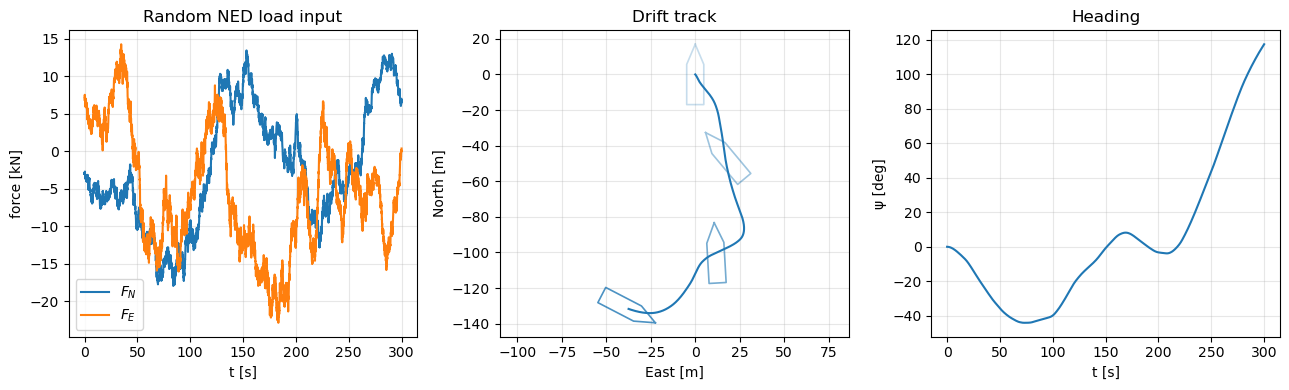

In [18]:
rng = np.random.default_rng(42)
T_run, n = 300.0, int(300.0 / DT)
t_grid = np.arange(n) * DT

def smooth_noise(scale, corr_steps=1200):
    # filtered white noise -> slowly varying signal with std ~ scale
    w = rng.standard_normal(n)
    kernel = np.ones(corr_steps) / corr_steps
    s = np.convolve(w, kernel, mode="same")
    return scale * s / s.std()

FN_t, FE_t = smooth_noise(8e3), smooth_noise(8e3)     # NED forces [N]
Mz_t = smooth_noise(150e3)                            # yaw moment [Nm]

def random_env(t, eta, nu):
    k = min(int(round(t / DT)), n - 1)
    f_body = Rz(eta[5]).T @ np.array([FN_t[k], FE_t[k], 0.0])
    return [f_body[0], f_body[1], 0.0, 0.0, 0.0, Mz_t[k]]

r = plant.run(T=T_run, thrust_command=no_thrust, azimuth_command=no_thrust,
              external=random_env, eta0=ETA0)
t, eta = r["t"], r["eta"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].plot(t_grid, FN_t / 1e3, label="$F_N$")
axes[0].plot(t_grid, FE_t / 1e3, label="$F_E$")
axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("force [kN]")
axes[0].set_title("Random NED load input"); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(eta[:, 1], eta[:, 0])
for k in np.linspace(0, len(eta) - 1, 4).astype(int):
    draw_vessel(axes[1], eta[k, 0], eta[k, 1], eta[k, 5], color="C0",
                alpha=0.25 + 0.55 * k / (len(eta) - 1))
axes[1].set_xlabel("East [m]"); axes[1].set_ylabel("North [m]")
axes[1].set_title("Drift track"); axes[1].grid(True, alpha=0.3); axes[1].axis("equal")

axes[2].plot(t, np.rad2deg(eta[:, 5]))
axes[2].set_xlabel("t [s]"); axes[2].set_ylabel("ψ [deg]")
axes[2].set_title("Heading"); axes[2].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

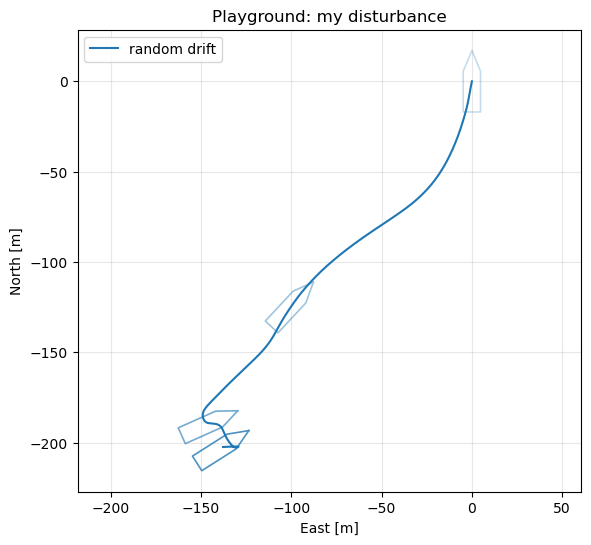

heading range: 0.0° … 98.0°


In [19]:
# ▶ Playground: roll your own disturbance — new seed, stronger loads, choppier signal.
rng = np.random.default_rng(7)          # <- new seed = new realization
FN_t, FE_t = smooth_noise(15e3, 600), smooth_noise(15e3, 600)   # stronger, faster forces
Mz_t = smooth_noise(300e3, 600)                                 # stronger yaw moment

r = plant.run(T=T_run, thrust_command=no_thrust, azimuth_command=no_thrust,
              external=random_env, eta0=ETA0)
eta = r["eta"]
plot_tracks({"random drift": eta}, "Playground: my disturbance", n_ships=4)
print(f"heading range: {np.rad2deg(eta[:, 5].min()):.1f}° … {np.rad2deg(eta[:, 5].max()):.1f}°")

## Takeaways

When you plug in your own models, use these tests as sanity checks:

- **Signs**: azimuths ahead → North (at $\psi = 0$); tunnel + → bow to starboard →
  positive $\psi$.
- **Actuator modes**: with `thruster_dynamics=True`, commands are not applied instantly —
  thrust ramps, azimuths rotate at finite speed, and thrust saturates at $u_{max}$.
  Part 1 runs with the dynamics OFF (ideal actuators): the plant applies your commands
  *exactly*, with no rate limits and no saturation — so respecting $u_{max}$ is your
  thrust allocation's responsibility from day one. The switch lets you preview the
  more realistic actuator behavior.
- **Conventions**: current and this notebook's NED forces use "towards"; a drift in the
  opposite direction of what you expect means a convention or rotation error.
- **Frames**: thruster commands and wind/wave loads live in BODY; positions in NED. At
  $\psi = 0$ the frames coincide and a missing $J^\top(\psi)$ is invisible — always test
  your environment models at a non-zero heading (`eta0=[0, 0, 0, 0, 0, psi0]`).
- **Coupling**: no single actuator produces a pure motion — sway commands create yaw,
  the tunnel creates sway. This is what makes thrust allocation a real problem.

Every section ends with a ▶ Playground cell — edit its numbers (and `ETA0` in the
harness cell) and re-run. The plant API accepts arbitrary commands and load callables
`load(t, eta, nu)` returning a 6-DOF BODY wrench.